# `09_ML.ipynb`
`uv add scikit-learn pandas matplotlib`

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

import warnings

warnings.filterwarnings('ignore')

In [2]:
# 도미
bream_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0,
                31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0,
                35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0]
bream_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0,
                500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0,
                700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0]
# 빙어
smelt_length = [9.8, 10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
smelt_weight = [6.7, 7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

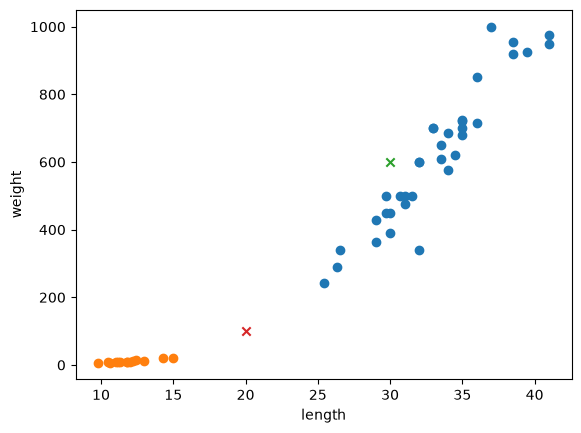

In [12]:
plt.scatter(bream_length, bream_weight)
plt.scatter(smelt_length, smelt_weight)

plt.scatter([30], [600], marker='x')
plt.scatter([20], [100], marker='x')
plt.xlabel('length')
plt.ylabel('weight')
plt.show()

## KNN (K-Nearest Neighbors)

In [4]:
# 도미 데이터프레임(표)
bream_df = pd.DataFrame({
    'l': bream_length,
    'w': bream_weight,
    'c': [1] * len(bream_length)  # 카테고리1: 도미
})

# 빙어 데이터프레임(표)
smelt_df = pd.DataFrame({
    'l': smelt_length,
    'w': smelt_weight,
    'c': [0] * len(smelt_length)  # 카테고리0: 빙어
})

# 최종 데이터 프레임
df = pd.concat([bream_df, smelt_df], ignore_index=True)

# df의 앞 5개 row만 보기
df.head()

,l,w,c
0,25.4,242.0,1
1,26.3,290.0,1
2,26.5,340.0,1
3,29.0,363.0,1
4,29.0,430.0,1


In [10]:
# df 에 들어있는 데이터(생선의 길이, 무게, 종류)를 학습시킴

from sklearn.neighbors import KNeighborsClassifier

kn = KNeighborsClassifier()
# 원본df의 특정 컬럼만 뽑은것
X = df[['l', 'w']]
y = df['c']

# fit=학습. X는 데이터, y는 답
_ = kn.fit(X, y)

In [11]:
kn.score(X, y)

1.0

In [ ]:
kn.predict([
    [30, 600],  # 1번 케이스 -> c: 1 -> 도미
    [20, 100],  # 2번 케이스 -> c: 0 -> 빙어
])

array([1, 0])

In [ ]:
# 문제 1 -> K의 개수가 커지면? (현재 전체 데이터 개수 49)
kn49 = KNeighborsClassifier(n_neighbors=49)
_ = kn49.fit(X, y)  # 무조건 도미로 판단하는 분류기
kn49.score(X, y)  # 0.74xxx -> 35/49

# 현재 도미 35, 빙어 14
kn49.predict([
    [1, 1],
    [1000, 1000]
])

array([1, 1])